In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
import tensorflow as tf

# loading MNIST datasets

In [4]:
mnist= tf.keras.datasets.mnist

# after loading the dataset, divide into training and test dataset

In [5]:
#unpack the data into training and testing dataset
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [6]:
X_train[0].shape

(28, 28)

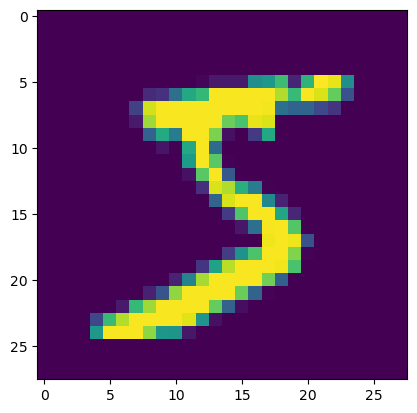

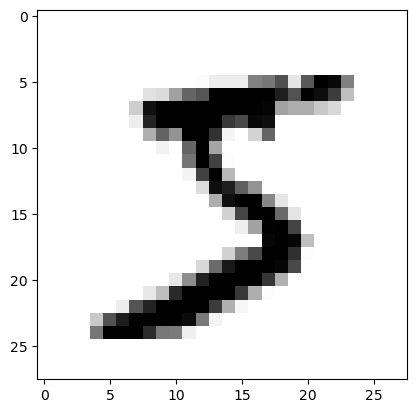

In [7]:
import matplotlib.pyplot as plt
# just check how the dataset looks
plt.imshow(X_train[0])
plt.show()
#inorder to execute the graph 
# we don't know the color image or binary image 
#inorder to plot, we change the configuration
plt.imshow(X_train[0],cmap=plt.cm.binary)

# checking the value of pixel before 
# Normalization

In [8]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

# as images are in gray level(1 channel ==>0 to 255),not colores(RGB)

# normalizing the data|pre processing step

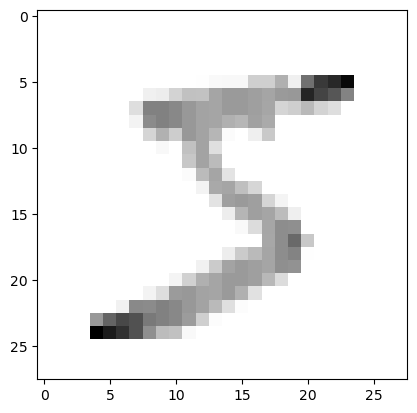

In [9]:
### As you might notice, its gray image; all values vary from 0 to 255
### to normalize to it 
X_train = tf.keras.utils.normalize(X_train,axis=1)
X_test= tf.keras.utils.normalize(X_test,axis=1)
plt.imshow(X_train[0],cmap=plt.cm.binary)

In [10]:
print(X_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [11]:
print(y_train[0]) # as we need to check label inside our network

5


# resizing image to make it suitable for apply convolution operation

In [12]:
import numpy as np
img_size=28
x_trainr = np.array(X_train).reshape(-1,img_size,img_size,1)# increasing one dimension for kernel operation
x_testr = np.array(X_test).reshape(-1,img_size,img_size,1)# increasing one dimension for kernel operation
print("Training samples dimension",x_trainr.shape)
print("testing sample dimension",x_testr.shape)

Training samples dimension (60000, 28, 28, 1)
testing sample dimension (10000, 28, 28, 1)


# Create a Deep neural network 
# training on 60,000 samples of mnist handwwritten dataset


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,Input

In [14]:
# creating a neural network
model = Sequential()
# input layer
model.add(Input(shape=x_trainr.shape[1:]))
### first convolution layer 0 1 2 3 (60000,28,28,2)
model.add(Conv2D(64,(3,3)))# only for first convolution layer to mention input layer size
model.add(Activation("relu"))## activation function to remove 0 
model.add(MaxPooling2D(pool_size=(2,2)))# maxpooling
#2nd convolutional layer
model.add(Conv2D(64,(3,3)))# only for first convolution layer to mention input layer size
model.add(Activation("relu"))## activation function to remove 0 
model.add(MaxPooling2D(pool_size=(2,2)))# maxpooling

#3rd convolutional layer
model.add(Conv2D(64,(3,3)))# only for first convolution layer to mention input layer size
model.add(Activation("relu"))## activation function to remove 0 
model.add(MaxPooling2D(pool_size=(2,2)))# maxpooling

# fully connected layer
model.add(Flatten())# before using full connected layer,need to be faltten so that 20 to 10
model.add(Dense(64))
model.add(Activation("relu"))

# fully connected layer 2
model.add(Dense(32))
model.add(Activation("relu"))
#fully connected layer 3
model.add(Dense(10))
model.add(Activation("softmax"))

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81,066 (316.66 KB)

 Trainable params: 81,066 (316.66 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
print("total training saamples",len(x_trainr))

total training saamples 60000


In [17]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [18]:
model.fit(x_trainr,y_train,epochs=5,validation_split=0.3)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8827 - loss: 0.3697 - val_accuracy: 0.9584 - val_loss: 0.1365
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9648 - loss: 0.1110 - val_accuracy: 0.9717 - val_loss: 0.0965
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9760 - loss: 0.0806 - val_accuracy: 0.9732 - val_loss: 0.0818
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9818 - loss: 0.0608 - val_accuracy: 0.9763 - val_loss: 0.0750
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9835 - loss: 0.0512 - val_accuracy: 0.9808 - val_loss: 0.0654


In [19]:
# evaluating on training dataset MNIT
test_loss,test_acc=model.evaluate(x_testr,y_test)
print("test_loss on 10000 test sample",test_loss)
print("validation accuracy on 10000 test sample",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9824 - loss: 0.0613
test_loss on 10000 test sample 0.06134679540991783
validation accuracy on 10000 test sample 0.9824000000953674


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted: 7
Actual: 7


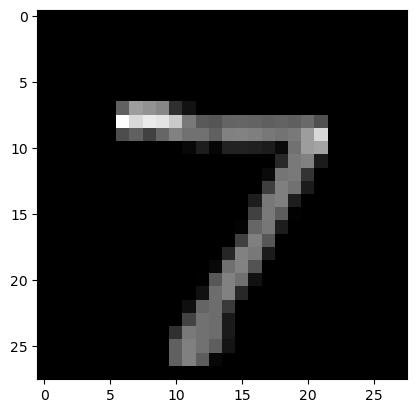

In [25]:
prediction = model.predict(x_testr)

print("Predicted:", np.argmax(prediction[0]))
print("Actual:", y_test[0])

plt.imshow(X_test[0], cmap="gray")
plt.show()

Predicted: 8
Actual: 8


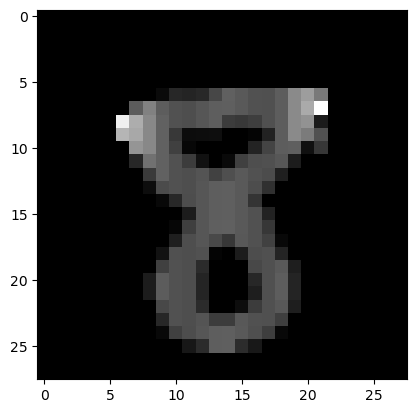

In [21]:


print("Predicted:", np.argmax(prediction[128]))
print("Actual:", y_test[128])

plt.imshow(X_test[128], cmap="gray")
plt.show()

In [22]:
import cv2

In [24]:
# After reading the image
img = cv2.imread("img2.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ADD THIS - Invert the image colors
gray = cv2.bitwise_not(gray)  # <-- This inverts black to white and vice versa

resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)
newing = tf.keras.utils.normalize(resized, axis=1)
newing = np.array(newing).reshape(-1, img_size, img_size, 1)

predictions = model.predict(newing)
print(np.argmax(predictions))  # Should now give correct prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6
